# Counting Molecules: Project Overview & Data Inspection

This notebook serves as the **initial data inspection and project framework overview** for the ADS2002 *Counting Molecules* project.

### Key Objectives of this Notebook:
1. Scan and inspect all 14 STM data files (`.p` pickle and `.sxm` Nanonis formats) in `ProjectData`.
2. Provide a unified parser interface and master summary table.
3. Display a complete 14-image contact sheet for quick visual inspection.
4. Summarize the overall project mission, data taxonomy, and analytical roadmap at the conclusion.

---


In [1]:
from pathlib import Path
import math
import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)


In [2]:
# Metadata separates molecular species from experimental/acquisition condition
CLASSIFICATION_METADATA = {
    "Hellerstedt APT/111_test_data.p": {
        "species": "APT",
        "condition": "Baseline",
        "difficulty": "Level 1 (Easy)",
        "shape_type": "Isolated Spots / 3-lobe",
        "is_duplicate": True,
        "duplicate_of": "Hellerstedt APT/Ag111_APT_111.sxm",
        "notes": "Duplicate of Ag111_APT_111.sxm. Baseline test image."
    },
    "Hellerstedt APT/Ag111_APT_111.sxm": {
        "species": "APT",
        "condition": "Baseline",
        "difficulty": "Level 1 (Easy)",
        "shape_type": "Isolated Spots / 3-lobe",
        "is_duplicate": True,
        "duplicate_of": "Hellerstedt APT/111_test_data.p",
        "notes": "Duplicate of 111_test_data.p (512x512, 50x50nm)."
    },
    "Hellerstedt APT/Ag111_APT_007.sxm": {
        "species": "APT",
        "condition": "Baseline",
        "difficulty": "Level 1 (Easy)",
        "shape_type": "Dispersed Monomers",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "100nm FOV, low coverage, well-separated monomers."
    },
    "Hellerstedt APT/Ag111_APT_008.sxm": {
        "species": "APT",
        "condition": "Baseline",
        "difficulty": "Level 1 (Easy)",
        "shape_type": "Dispersed Monomers",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "100nm FOV sequence sample, no overlap."
    },
    "Hellerstedt APT/Ag111_APT_009.sxm": {
        "species": "APT",
        "condition": "Baseline",
        "difficulty": "Level 1 (Easy)",
        "shape_type": "Dispersed Monomers",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "100nm FOV sequence sample, flat substrate."
    },
    "Hellerstedt APT/Ag111_APT_010.sxm": {
        "species": "APT",
        "condition": "Baseline",
        "difficulty": "Level 1 (Easy)",
        "shape_type": "Dispersed Monomers",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "100nm FOV sequence sample."
    },
    "Hellerstedt APT/Ag111_APT_CO_044.p": {
        "species": "APT",
        "condition": "CO-functionalized tip",
        "difficulty": "Level 3 (Medium-Hard)",
        "shape_type": "High Contrast Blobs",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "CO-functionalized tip, high contrast, strong slope background."
    },
    "Hellerstedt APT/Ag111_APT_LL1s_UV9min_009.sxm": {
        "species": "APT",
        "condition": "UV irradiation (9 min)",
        "difficulty": "Level 2 (Medium)",
        "shape_type": "Aggregated Clusters",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "UV 9min irradiation, local crowding; Watershed required."
    },
    "Hellerstedt APT/Ag111_APT_UV21min_anneal_003.sxm": {
        "species": "APT",
        "condition": "UV irradiation (21 min) + annealing",
        "difficulty": "Level 2 (Medium)",
        "shape_type": "Aggregated Reaction Motifs",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "UV 21min + annealing, high molecular density."
    },
    "Hellerstedt APT/Ag111_APT_UV21min_anneal_40min_018.sxm": {
        "species": "APT",
        "condition": "UV irradiation (21 min) + annealing (40 min)",
        "difficulty": "Level 2 (Medium)",
        "shape_type": "Aggregated Reaction Motifs",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "Annealing 40min reaction morphology."
    },
    "Castelli MgPc/180509_18-16-48_SPM001.sxm": {
        "species": "MgPc",
        "condition": "Not specified",
        "difficulty": "Level 3 (Medium-Hard)",
        "shape_type": "Cross / Four-lobe Star",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "Large cross-shaped molecules, scan line noise; line fit needed."
    },
    "Stetsovych Helicene/Helicene_Ag(111)008.sxm": {
        "species": "Helicene",
        "condition": "Not specified",
        "difficulty": "Level 1 (Easy)",
        "shape_type": "Square / Rhombic Ring",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "Helicene molecules, clear geometric structure for shape fingerprints."
    },
    "Stetsovych Helicene/Helicene_Ag(111)020.sxm": {
        "species": "Helicene",
        "condition": "Not specified",
        "difficulty": "Level 1 (Easy)",
        "shape_type": "Square / Rhombic Ring",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "Helicene molecules with symmetric geometry."
    },
    "Stetsovych Helicene/Helicene_Ag(111)021.sxm": {
        "species": "Helicene",
        "condition": "Not specified",
        "difficulty": "Level 4 (Hard)",
        "shape_type": "Square Ring + Bright Edge Artifact",
        "is_duplicate": False,
        "duplicate_of": None,
        "notes": "Very bright step edge at bottom right; ROI Masking mandatory."
    }
}


In [3]:
# Locate ProjectData folder
PROJECTDATA_CANDIDATES = [
    Path(r'/Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/ProjectData'),
    Path.cwd(),
    Path.cwd() / 'ProjectData',
    Path.cwd() / '选题' / 'CountingMolecules' / 'ProjectData',
    Path.cwd().parent / 'ProjectData',
]

PROJECTDATA = None
for candidate in PROJECTDATA_CANDIDATES:
    if (candidate / 'quick notes for viewing image data.txt').exists():
        PROJECTDATA = candidate.resolve()
        break

if PROJECTDATA is None:
    raise FileNotFoundError('Could not locate the Counting Molecules ProjectData folder.')

print('Using ProjectData:', PROJECTDATA)

p_files = sorted(PROJECTDATA.rglob('*.p'))
sxm_files = sorted(PROJECTDATA.rglob('*.sxm'))
all_files = p_files + sxm_files
print(f'Scanned: {len(p_files)} .p files and {len(sxm_files)} .sxm files (Total {len(all_files)} images).')


Using ProjectData: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/ProjectData
Scanned: 2 .p files and 12 .sxm files (Total 14 images).


In [4]:
def _numbers_from_line(line, cast=float):
    return [cast(x) for x in line.strip().split()]

def _section_value(lines, key, default=None):
    try:
        i = lines.index(key)
    except ValueError:
        return default
    if i + 1 >= len(lines):
        return default
    return lines[i + 1].strip()

def _parse_data_info(lines):
    try:
        start = lines.index(':DATA_INFO:') + 1
    except ValueError:
        return []
    rows = []
    for line in lines[start:]:
        if not line.strip() or line.startswith(':'): break
        parts = line.strip().split('\t')
        if parts and parts[0] == 'Channel': continue
        if len(parts) >= 6:
            rows.append({'channel': parts[0], 'name': parts[1], 'unit': parts[2], 'direction': parts[3], 'calibration': float(parts[4]), 'offset': float(parts[5])})
    return rows

def read_sxm_fallback(path):
    path = Path(path)
    raw = path.read_bytes()
    marker = b':SCANIT_END:'
    marker_index = raw.find(marker)
    header_text = raw[:marker_index].decode('latin1', errors='replace')
    lines = header_text.splitlines()
    data_start = marker_index + len(marker)
    while data_start < len(raw) and raw[data_start] in b'\r\n\x1a\x04': data_start += 1
    nx, ny = _numbers_from_line(_section_value(lines, ':SCAN_PIXELS:'), int)[:2]
    scan_range = _numbers_from_line(_section_value(lines, ':SCAN_RANGE:', 'nan nan'), float)[:2]
    scan_dir = _section_value(lines, ':SCAN_DIR:', '')
    data_info = _parse_data_info(lines)
    frames = []
    for row in data_info:
        directions = ['forward', 'backward'] if row['direction'].lower() == 'both' else [row['direction'].lower()]
        for direction in directions: frames.append({**row, 'frame_direction': direction})
    expected_bytes = len(frames) * nx * ny * 4
    data_bytes = raw[data_start:data_start + expected_bytes]
    data = np.frombuffer(data_bytes, dtype='>f4').reshape((len(frames), ny, nx)).astype(float)
    data[data > 1e30] = np.nan
    return {'path': path, 'scan_pixels': np.array([nx, ny]), 'scan_range': np.array(scan_range), 'scan_dir': scan_dir, 'frames': frames, 'data': data}

def read_sxm_image(path):
    path = Path(path)
    try:
        import nanonispy as nap
        scan = nap.read.Scan(str(path))
        image = np.array(scan.signals['Z']['forward'], dtype=float)
        scan_dir = scan.header.get('scan_dir', '')
        if str(scan_dir).lower() == 'down': image = np.flipud(image)
        if np.isnan(image).any(): image = np.where(np.isnan(image), np.nanmean(image), image)
        scan_pixels = np.array(scan.header.get('scan_pixels', image.shape[::-1]))
        scan_range = np.array(scan.header.get('scan_range', [np.nan, np.nan]), dtype=float)
        return image, {'rescale': scan_range / scan_pixels}
    except Exception:
        parsed = read_sxm_fallback(path)
        frames = parsed['frames']
        idx = next((i for i, f in enumerate(frames) if f['name'] == 'Z' and f['frame_direction'] == 'forward'), 0)
        image = parsed['data'][idx].copy()
        if str(parsed.get('scan_dir', '')).lower() == 'down': image = np.flipud(image)
        if np.isnan(image).any(): image = np.where(np.isnan(image), np.nanmean(image), image)
        scan_pixels = parsed['scan_pixels']
        scan_range = parsed['scan_range']
        return image, {'rescale': scan_range / scan_pixels}

def read_pickle_image(path):
    path = Path(path)
    with path.open('rb') as f: obj = pickle.load(f)
    image = np.array(obj['image'], dtype=float)
    return image, {'rescale': np.array(obj['rescale']) if 'rescale' in obj else None}

def read_image_file(path):
    path = Path(path)
    rel_path = str(path.relative_to(PROJECTDATA))
    if path.suffix == '.p': image, metadata = read_pickle_image(path)
    elif path.suffix == '.sxm': image, metadata = read_sxm_image(path)
    else: raise ValueError(f'Unsupported file type: {path.suffix}')
    meta_cls = CLASSIFICATION_METADATA.get(rel_path, {"species": "Unknown", "condition": "Unknown", "difficulty": "Unclassified", "shape_type": "N/A", "is_duplicate": False, "notes": ""})
    return {'path': path, 'relative_path': rel_path, 'kind': path.suffix, 'image': image, 'shape': image.shape, **metadata, **meta_cls}


In [5]:
records = []
for path in all_files:
    rec = read_image_file(path)
    records.append(rec)

if pd is not None:
    rows = []
    for r in records:
        rescale = r.get("rescale")
        range_x = r["shape"][1] * rescale[0] if rescale is not None and rescale[0] is not None and not np.isnan(rescale[0]) else np.nan
        range_y = r["shape"][0] * rescale[1] if rescale is not None and rescale[1] is not None and not np.isnan(rescale[1]) else np.nan
        rows.append({
            "file": r["relative_path"],
            "species": r["species"],
            "condition": r["condition"],
            "difficulty": r["difficulty"],
            "shape_type": r["shape_type"],
            "duplicate?": "Yes" if r["is_duplicate"] else "No",
            "resolution": f"{r['shape'][0]}x{r['shape'][1]}",
            "fov_nm": f"{range_x:.1f}x{range_y:.1f}" if not np.isnan(range_x) else "N/A",
            "notes": r["notes"]
        })
    df = pd.DataFrame(rows)
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))


,file,species,condition,difficulty,shape_type,duplicate?,resolution,fov_nm,notes
0,Hellerstedt APT/111_test_data.p,APT,Baseline,Level 1 (Easy),Isolated Spots / 3-lobe,Yes,512x512,0.0x0.0,Duplicate of Ag111_APT_111.sxm. Baseline test ...
1,Hellerstedt APT/Ag111_APT_CO_044.p,APT,CO-functionalized tip,Level 3 (Medium-Hard),High Contrast Blobs,No,1024x1024,0.0x0.0,"CO-functionalized tip, high contrast, strong s..."
2,Castelli MgPc/180509_18-16-48_SPM001.sxm,MgPc,Not specified,Level 3 (Medium-Hard),Cross / Four-lobe Star,No,768x768,0.0x0.0,"Large cross-shaped molecules, scan line noise;..."
3,Hellerstedt APT/Ag111_APT_007.sxm,APT,Baseline,Level 1 (Easy),Dispersed Monomers,No,1024x1024,0.0x0.0,"100nm FOV, low coverage, well-separated monomers."
4,Hellerstedt APT/Ag111_APT_008.sxm,APT,Baseline,Level 1 (Easy),Dispersed Monomers,No,1024x1024,0.0x0.0,"100nm FOV sequence sample, no overlap."
5,Hellerstedt APT/Ag111_APT_009.sxm,APT,Baseline,Level 1 (Easy),Dispersed Monomers,No,1024x1024,0.0x0.0,"100nm FOV sequence sample, flat substrate."
6,Hellerstedt APT/Ag111_APT_010.sxm,APT,Baseline,Level 1 (Easy),Dispersed Monomers,No,1024x1024,0.0x0.0,100nm FOV sequence sample.
7,Hellerstedt APT/Ag111_APT_111.sxm,APT,Baseline,Level 1 (Easy),Isolated Spots / 3-lobe,Yes,512x512,0.0x0.0,"Duplicate of 111_test_data.p (512x512, 50x50nm)."
8,Hellerstedt APT/Ag111_APT_LL1s_UV9min_009.sxm,APT,UV irradiation (9 min),Level 2 (Medium),Aggregated Clusters,No,1024x1024,0.0x0.0,"UV 9min irradiation, local crowding; Watershed..."
9,Hellerstedt APT/Ag111_APT_UV21min_anneal_003.sxm,APT,UV irradiation (21 min) + annealing,Level 2 (Medium),Aggregated Reaction Motifs,No,1024x1024,0.0x0.0,"UV 21min + annealing, high molecular density."


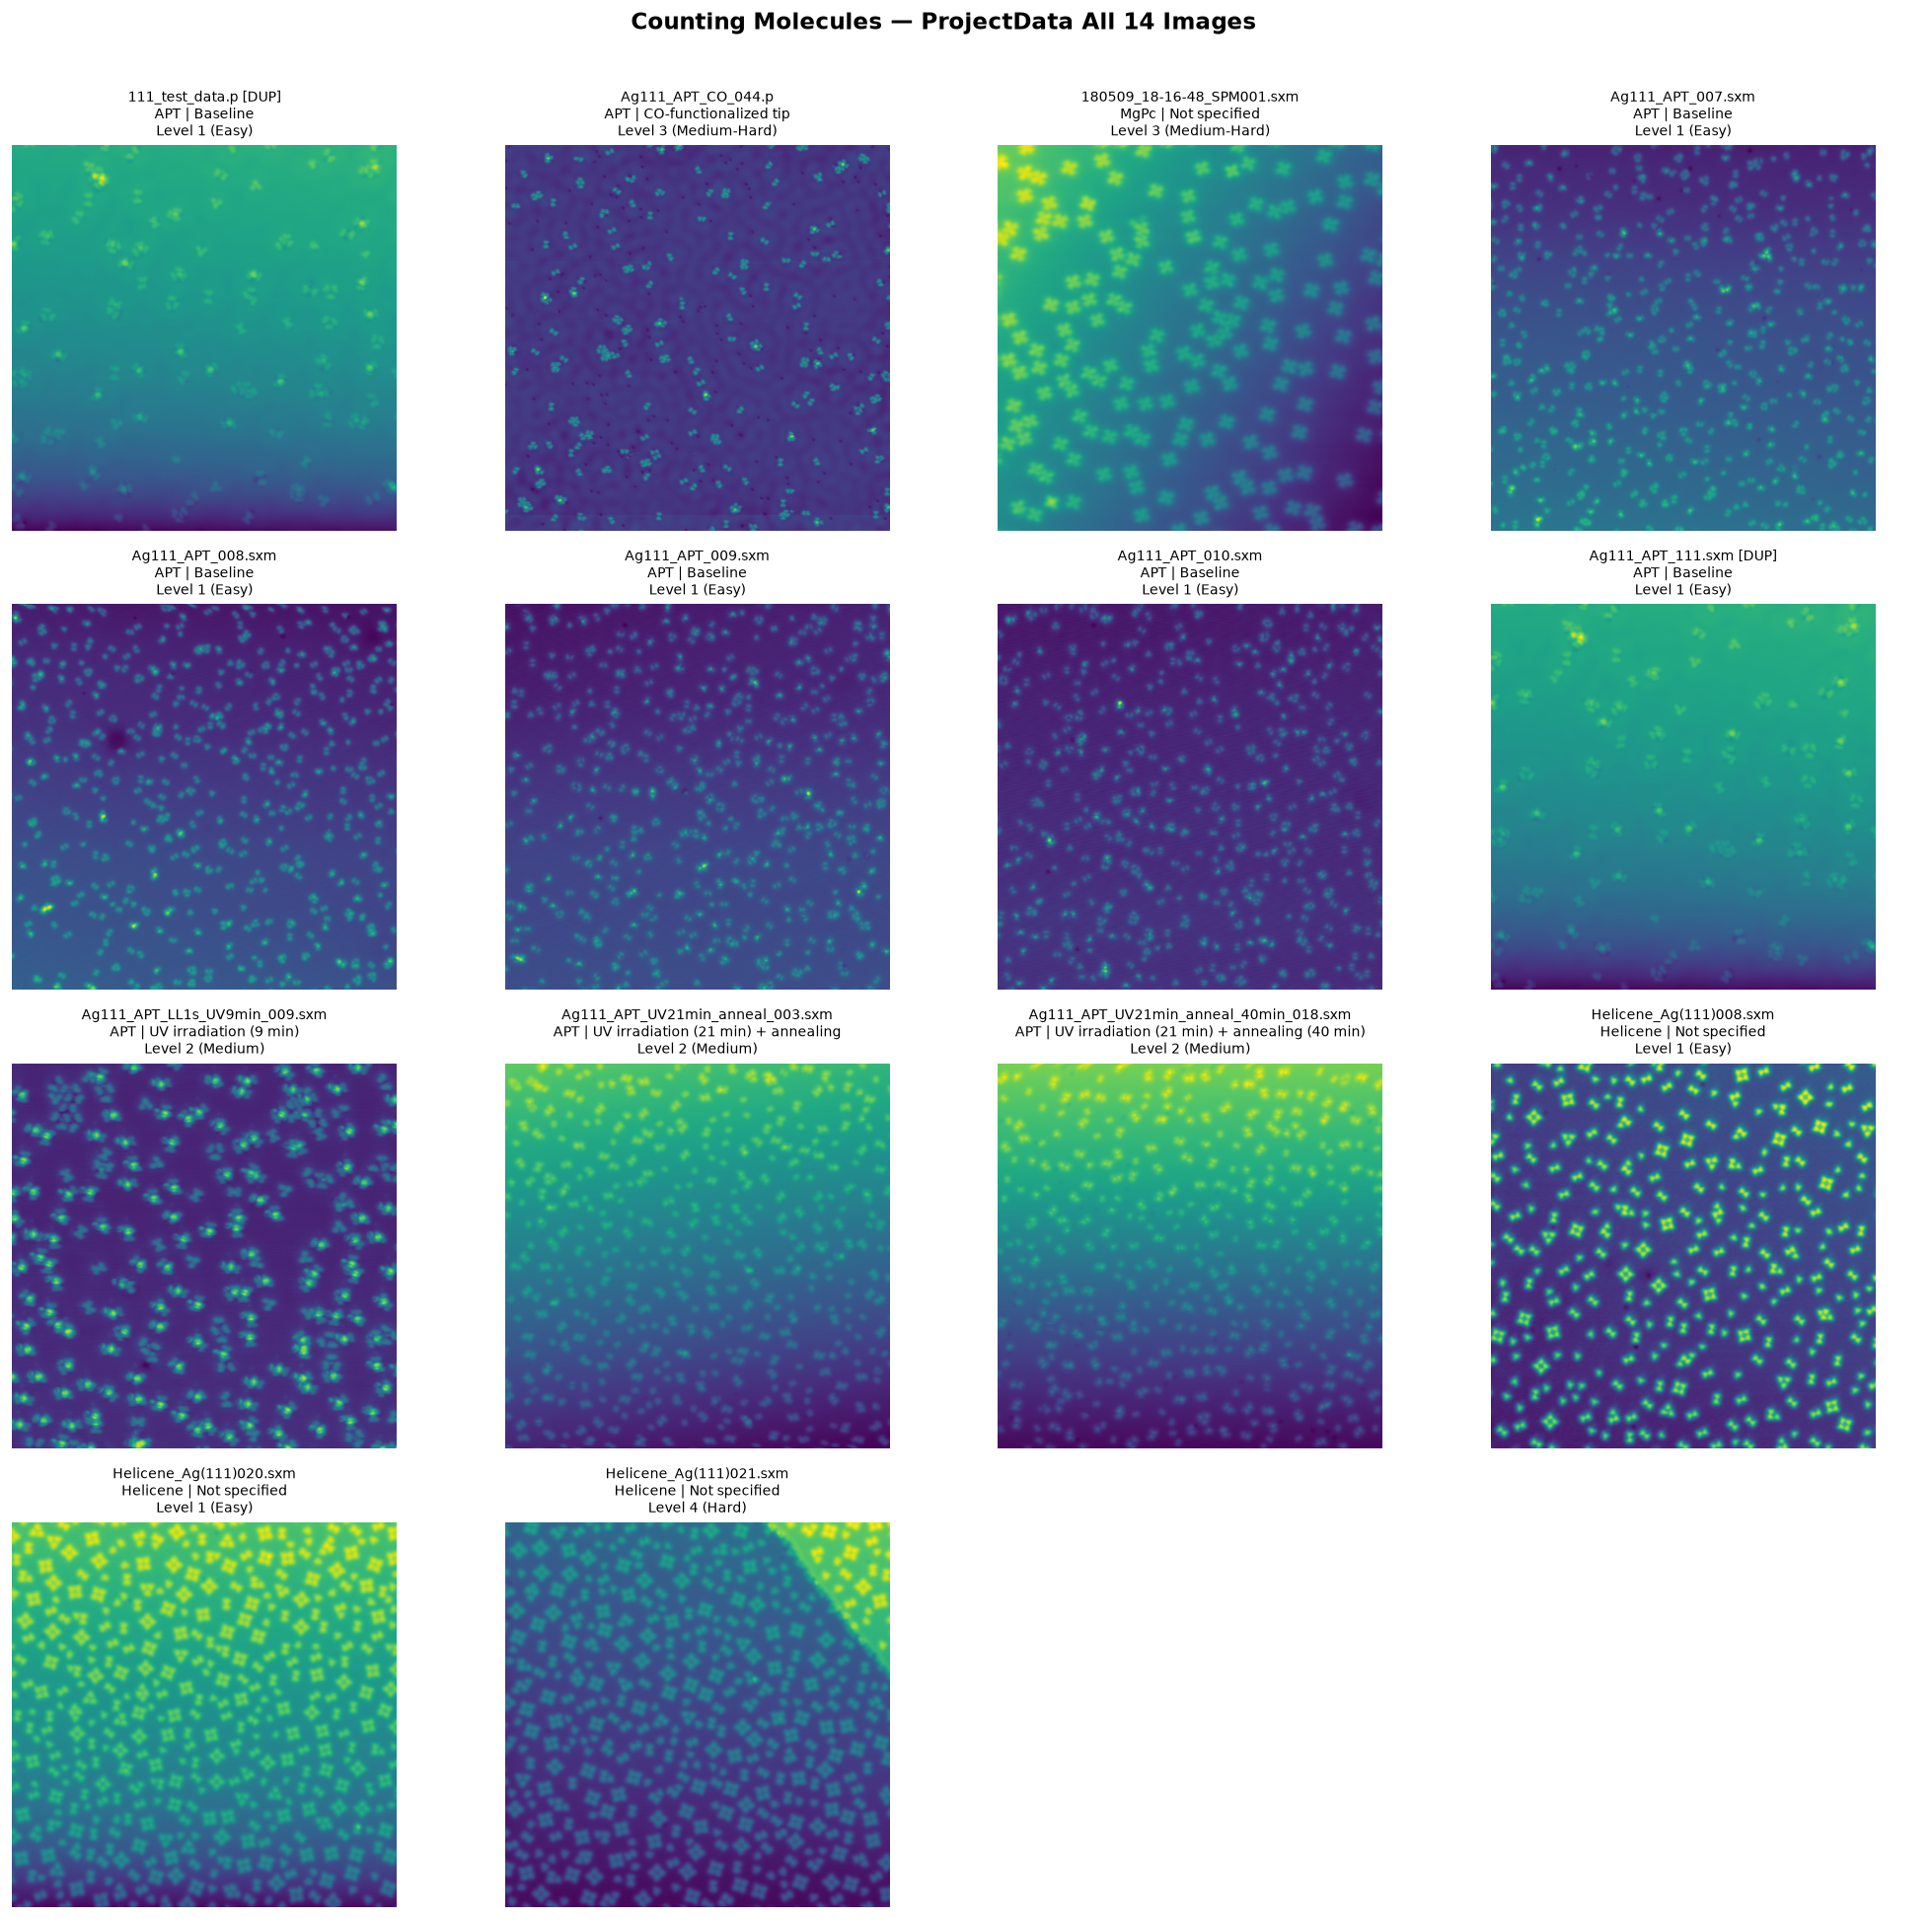

In [6]:
def show_all_contact_sheet(records, cols=4, cmap='viridis'):
    rows = math.ceil(len(records) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 4 * rows))
    axes = np.atleast_2d(axes)
    fig.suptitle('Counting Molecules — ProjectData All 14 Images', fontsize=14, fontweight='bold', y=1.01)
    
    for idx, rec in enumerate(records):
        r_idx, c_idx = divmod(idx, cols)
        ax = axes[r_idx, c_idx]
        ax.imshow(rec['image'], cmap=cmap, origin='lower')
        dup = " [DUP]" if rec.get("is_duplicate") else ""
        fname = rec["relative_path"].split("/")[-1]
        title = f'{fname}{dup}\n{rec["species"]} | {rec["condition"]}\n{rec["difficulty"]}'
        ax.set_title(title, fontsize=8.5)
        ax.axis('off')
        
    for idx in range(len(records), rows * cols):
        r_idx, c_idx = divmod(idx, cols)
        axes[r_idx, c_idx].axis('off')
        
    plt.tight_layout()
    plt.show()

show_all_contact_sheet(records)


## Species and Experimental Conditions
The complete dataset contains three molecular species: **APT**, **MgPc**, and **Helicene**. Within the Hellerstedt dataset, all files contain APT, so the meaningful comparison is between experimental or acquisition conditions rather than between species.

APT conditions represented in the filenames/metadata are: **Baseline**, **CO-functionalized tip**, **UV irradiation (9 min)**, and **UV irradiation (21 min) + annealing**. `shape_type` remains a separate observed outcome rather than an experimental condition.


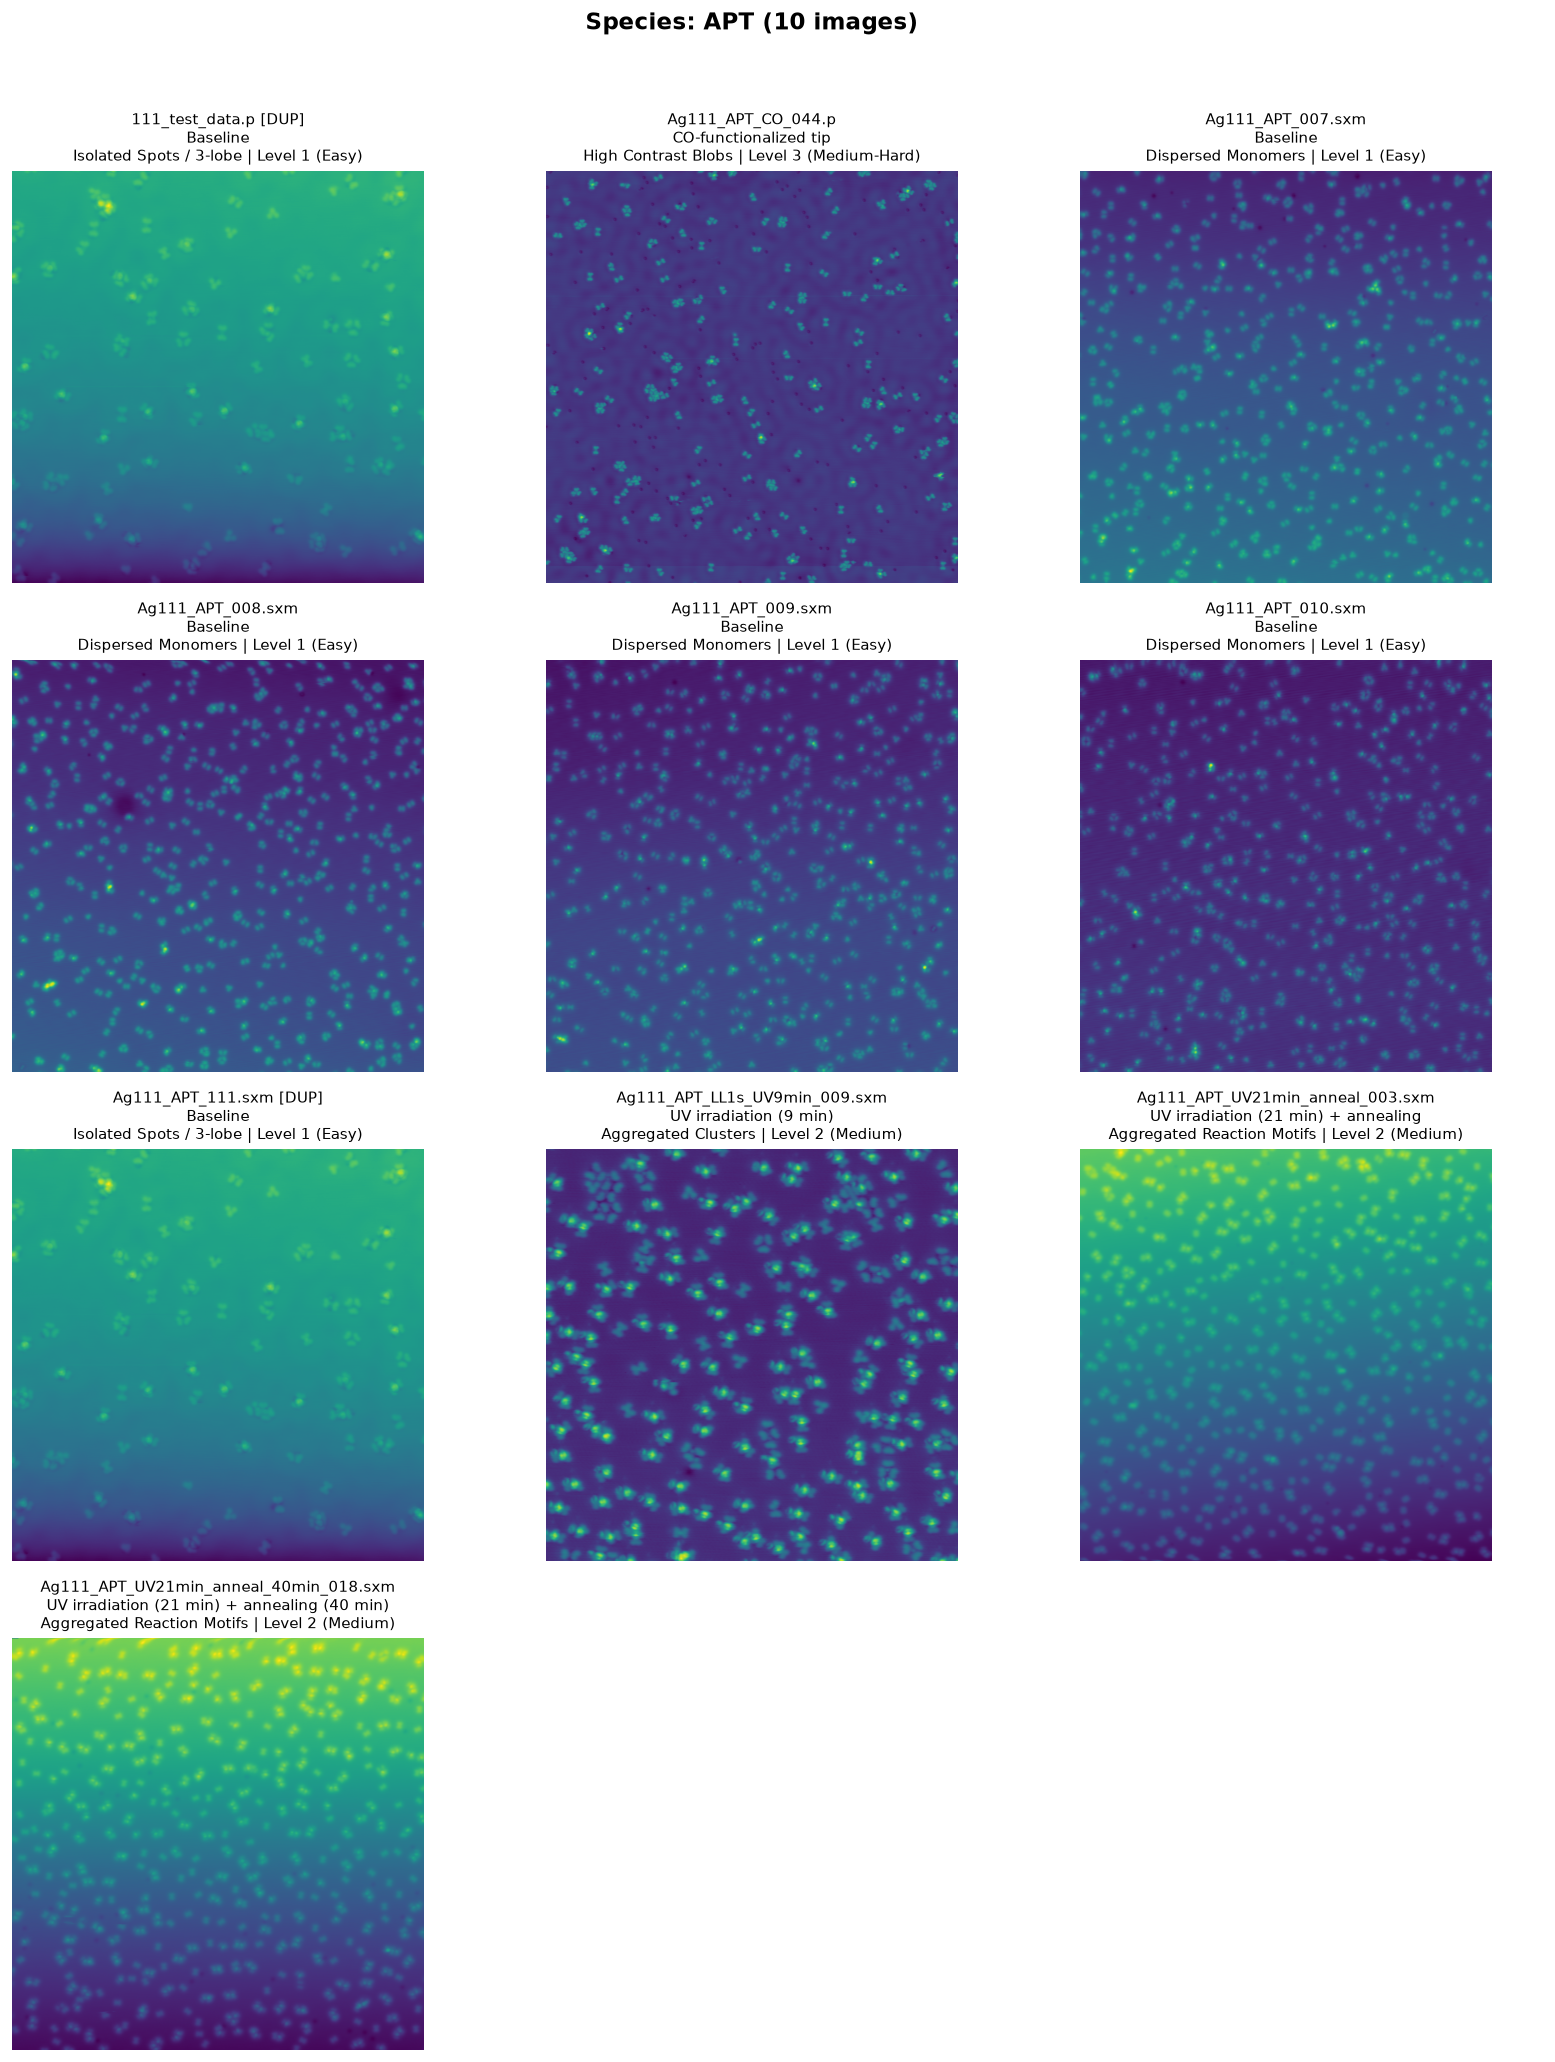

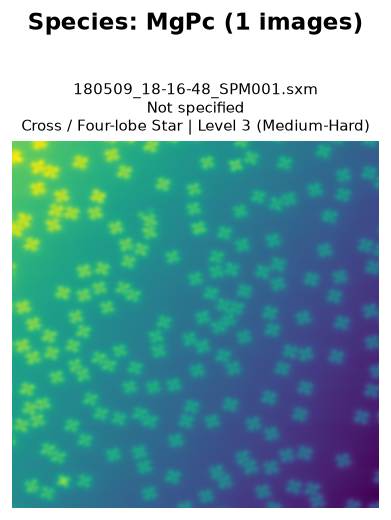

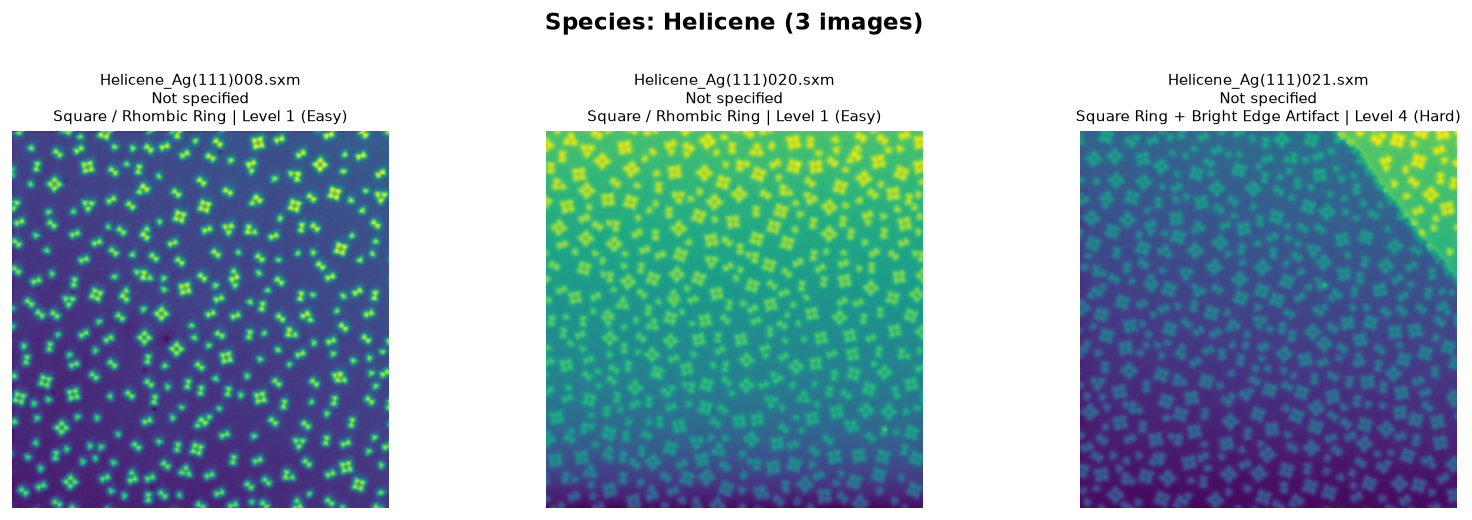

In [7]:
def show_by_species(records, cmap='viridis'):
    species_groups = {}
    for r in records:
        sp = r['species']
        species_groups.setdefault(sp, []).append(r)
    
    for sp_name, group_recs in species_groups.items():
        cols = min(3, len(group_recs))
        rows = math.ceil(len(group_recs) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4.2 * rows))
        if rows == 1 and cols == 1:
            axes = np.array([[axes]])
        elif rows == 1 or cols == 1:
            axes = np.atleast_2d(axes)
            if rows == 1: axes = axes.reshape(1, -1)
        fig.suptitle(f'Species: {sp_name} ({len(group_recs)} images)', fontsize=14, fontweight='bold', y=1.02)
        for idx, rec in enumerate(group_recs):
            r_idx, c_idx = divmod(idx, cols)
            ax = axes[r_idx, c_idx]
            ax.imshow(rec['image'], cmap=cmap, origin='lower')
            dup = " [DUP]" if rec.get("is_duplicate") else ""
            fname = rec["relative_path"].split("/")[-1]
            ax.set_title(f'{fname}{dup}\n{rec["condition"]}\n{rec["shape_type"]} | {rec["difficulty"]}', fontsize=9)
            ax.axis('off')
        for idx in range(len(group_recs), rows * cols):
            r_idx, c_idx = divmod(idx, cols)
            axes[r_idx, c_idx].axis('off')
        plt.tight_layout()
        plt.show()

show_by_species(records)


---
## Project Summary & Analytical Roadmap

### 1. Core Mission
This ADS2002 **Counting Molecules** project aims to develop an automated pipeline using Python image-processing libraries (`scikit-image`, `SciPy`, `NumPy`) and machine-learning tools (`scikit-learn`) to:
- **Detect and segment** individual molecules from Scanning Tunneling Microscopy (STM) images.
- **Count** the number of candidate molecules in each image.
- **Classify (sort)** molecules into distinct species and compare APT results across experimental conditions.
- **Validate** automated results against hand-counted ground truth.

---

### 2. Dataset Structure
`ProjectData` contains **14 image files** (2 `.p` pickle + 12 `.sxm` Nanonis), covering **3 molecular species**. Species and condition are stored as separate variables:

| Species | Source folder | Files | Conditions | Morphological Features |
| :--- | :--- | :---: | :--- | :--- |
| **APT** | Hellerstedt APT | 10 | Baseline, CO-tip, UV 9 min, UV 21 min + annealing | Small bright spots, 3-lobe motifs, aggregated clusters |
| **MgPc** | Castelli MgPc | 1 | Not specified | Large cross / four-lobe star-shaped molecules |
| **Helicene** | Stetsovych Helicene | 3 | Not specified | Square, rhombic, or ring-shaped twisted structures |

> **Important**: `111_test_data.p` and `Ag111_APT_111.sxm` contain identical data (512x512, 50x50 nm). They must be treated as a single sample. The actual number of unique images is **13**.

---


### 3. Analytical Objectives
The downstream analysis (to be implemented in a separate notebook) consists of five key stages:

1. **Background Flattening & Noise Reduction**: Apply 2D plane fitting and line-by-line median subtraction to remove tilted backgrounds and scan-line artifacts (critical for `CO_044.p` and `Castelli MgPc`).
2. **Artifact ROI Masking**: Mask the extremely bright step-edge region in `Helicene_Ag(111)021.sxm` to prevent global thresholding distortion.
3. **Segmentation & Cluster Splitting**: Use adaptive thresholding with morphological operations, followed by distance-transform watershed to separate touching/aggregated molecules (critical for UV-irradiated APT images).
4. **Feature Extraction (Molecular Fingerprinting)**: Extract `regionprops` features for each detected molecule, including Area, Perimeter, Eccentricity, Solidity, Aspect Ratio, and Mean Intensity.
5. **Automated Counting & Comparative Analysis**: Output per-image molecule counts, distinguish APT, MgPc, and Helicene where appropriate, and compare APT count/density/morphology across experimental conditions. Validate results against hand-counted baselines when annotations are available.

---
